# 🔍 Customer Churn Intelligence System — Production Edition

Notebook ini adalah versi **production-ready** yang menggabungkan:
- ✅ **EDA mendalam** — memahami pola churn sebelum modelling
- ✅ **Sentiment Analysis modern** (Sentence Transformers) — semantic meaning, bukan sekadar word count
- ✅ **Feature Engineering** — fitur turunan bermakna seperti di level industri
- ✅ **Model Comparison + Cross-Validation** — 3 model dibandingkan secara ketat
- ✅ **SHAP Explainability** — jawab *"kenapa customer ini churn?"*
- ✅ **Risk Scoring + Rekomendasi Bisnis** — output siap pakai untuk stakeholder
- ✅ **FastAPI Deployment-Ready** — satu pipeline + artefak terorganisir untuk di-serve

---
## Arsitektur Sistem

```
Raw Data (CSV)
     │
     ▼
[Phase 1] Data Cleaning & Validation
     │
     ▼
[Phase 2] EDA — Pahami pola churn
     │
     ▼
[Phase 3] Sentence Transformers Embeddings (modern NLP)
     │
     ▼
[Phase 4] Feature Engineering (fitur tabular turunan)
     │
     ▼
[Phase 5] Model Training & CV Comparison (CatBoost, RF, GB)
     │
     ▼
[Phase 6] SHAP Explainability
     │
     ▼
[Phase 7] Risk Scoring + Business Recommendations
     │
     ▼
[Phase 8] Export Artefak → siap di-load FastAPI
```

> **Mengapa CatBoost sebagai model utama?**
> CatBoost unggul untuk data tabular dengan fitur kategorikal — tidak perlu OneHotEncoding manual,
> mendukung class weight otomatis, dan training-nya stabil. Cocok untuk dataset Telco Churn.

> **Mengapa Sentence Transformers menggantikan VADER/TF-IDF?**
> Sentence Transformers menangkap *makna semantik* teks. "Service is terrible" dan
> "I'm really unhappy with this provider" akan dikenali sebagai similar — sesuatu yang
> VADER atau TF-IDF tidak bisa lakukan dengan baik.


---
## ⚙️ Phase 0 — Setup & Dependencies

In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn catboost sentence-transformers shap joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

import os, re, json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sentence_transformers import SentenceTransformer
from catboost import CatBoostClassifier, Pool
import shap

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

# ── Konfigurasi ──────────────────────────────────────────────────────────────
RAW_DATA_PATH     = 'dataset/telco_churn_with_all_feedback.csv'
OUTPUT_DIR        = 'output'
MODEL_DIR         = 'models'
EMBED_MODEL_NAME  = 'sentence-transformers/all-MiniLM-L6-v2'
N_EMBED_COMPONENTS = 24      # komponen PCA dari embeddings (lebih kecil = lebih ringan)
RANDOM_STATE      = 42
TEST_SIZE         = 0.2
HIGH_RISK_THR     = 0.70
MED_RISK_THR      = 0.40

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,  exist_ok=True)
print("✅ Setup selesai.")

✅ Setup selesai.


---
## 🧹 Phase 1 — Data Loading & Cleaning

Langkah pertama: load data, validasi tipe kolom, dan buat label target numerik.

**Yang dilakukan di sini:**
- `TotalCharges` dikonversi ke numerik (ada nilai string kosong di data asli)
- `CustomerFeedback` yang kosong diisi string kosong agar tidak error di embedding
- Kolom tidak relevan (`customerID`, `PromptInput`, unnamed) di-drop
- Label target `ChurnLabel` dibuat sebagai integer (1 = churn, 0 = tidak)


In [3]:
# ── Load ─────────────────────────────────────────────────────────────────────
df = pd.read_csv(RAW_DATA_PATH)
print(f"Shape awal: {df.shape}")
print(f"Kolom: {df.columns.tolist()}")
df.head(3)

Shape awal: (7043, 23)
Kolom: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'PromptInput', 'CustomerFeedback']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,PromptInput,CustomerFeedback
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Write a realistic customer feedback based on t...,I have been using the DSL internet service fro...
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No,Write a realistic customer feedback based on t...,I have been a customer with this company for o...
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Write a realistic customer feedback based on t...,I recently signed up for DSL internet service ...


In [4]:
# ── Cleaning ─────────────────────────────────────────────────────────────────
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing = df.isna().sum()
missing_cols = missing[missing > 0]
if len(missing_cols):
    print("Missing values ditemukan:")
    print(missing_cols)
    df['TotalCharges'] = df['TotalCharges'].fillna(0)

df['CustomerFeedback'] = df['CustomerFeedback'].fillna('')

# Label target
df['ChurnLabel'] = (df['Churn'].astype(str).str.strip().str.lower() == 'yes').astype(int)

# Drop kolom tidak relevan
drop_cols = [c for c in df.columns if c in ('customerID', 'PromptInput') or c.lower().startswith('unnamed')]
if drop_cols:
    df.drop(columns=drop_cols, inplace=True)
    print(f"Kolom di-drop: {drop_cols}")

print(f"\nShape setelah cleaning : {df.shape}")
print(f"Churn rate             : {df['ChurnLabel'].mean()*100:.2f}%")
print(f"CustomerFeedback kosong: {(df['CustomerFeedback'].str.strip() == '').sum()} baris")
df.dtypes

Missing values ditemukan:
TotalCharges    11
dtype: int64
Kolom di-drop: ['customerID', 'PromptInput']

Shape setelah cleaning : (7043, 22)
Churn rate             : 26.54%
CustomerFeedback kosong: 0 baris


gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
CustomerFeedback     object
ChurnLabel            int64
dtype: object

---
## 📊 Phase 2 — Exploratory Data Analysis (EDA)

EDA adalah langkah wajib sebelum modelling — kita harus *benar-benar paham* data sebelum melatih model.
Tanpa EDA, kita tidak tahu fitur mana yang paling informatif, apakah ada class imbalance, dll.

**Yang diamati:**
- Distribusi churn (class imbalance?)
- Churn rate per contract, internet service, payment method
- Distribusi tenure & MonthlyCharges per kelompok churn


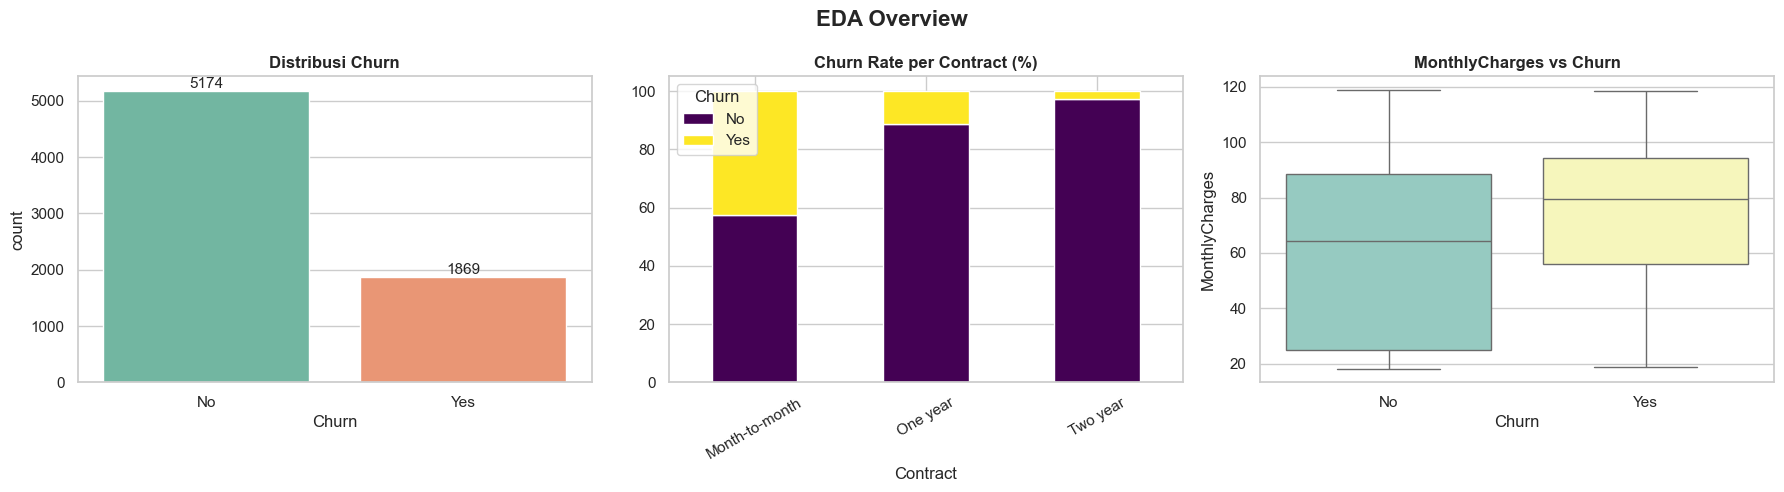

In [5]:
# ── Plot 1: Overview ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EDA Overview', fontsize=16, fontweight='bold')

# Distribusi churn
sns.countplot(data=df, x='Churn', ax=axes[0], palette='Set2', order=['No','Yes'])
axes[0].set_title('Distribusi Churn', fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x()+p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Churn rate per Contract
pd.crosstab(df['Contract'], df['Churn'], normalize='index').mul(100)  .plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title('Churn Rate per Contract (%)', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

# MonthlyCharges vs Churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[2],
            palette='Set3', order=['No','Yes'])
axes[2].set_title('MonthlyCharges vs Churn', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

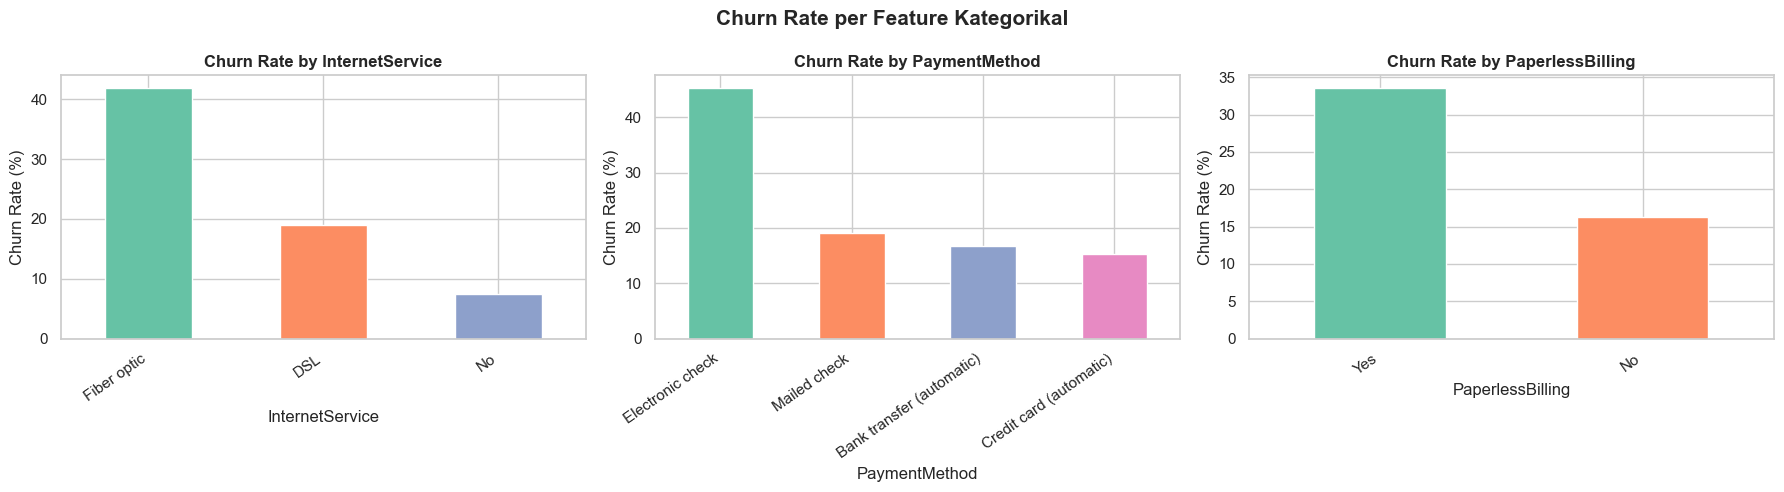

In [6]:
# ── Plot 2: Churn rate per kategori ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Churn Rate per Feature Kategorikal', fontsize=15, fontweight='bold')

for i, feat in enumerate(['InternetService', 'PaymentMethod', 'PaperlessBilling']):
    ct = df.groupby(feat)['ChurnLabel'].mean() * 100
    ct.sort_values(ascending=False).plot(kind='bar', ax=axes[i], color=sns.color_palette('Set2'))
    axes[i].set_title(f'Churn Rate by {feat}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=35, ha='right')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

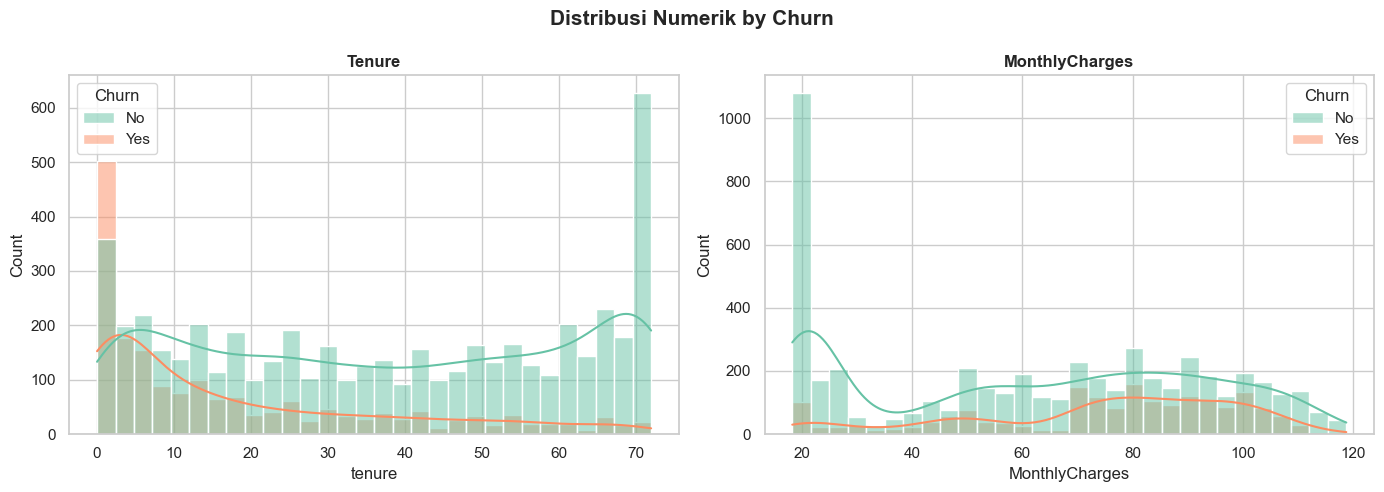

Statistik Kunci (Churn vs No Churn):
  tenure              : Churn=17.98  |  No Churn=37.57
  MonthlyCharges      : Churn=74.44  |  No Churn=61.27
  TotalCharges        : Churn=1531.80  |  No Churn=2549.91


In [7]:
# ── Plot 3: Distribusi numerik ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Numerik by Churn', fontsize=15, fontweight='bold')

sns.histplot(data=df, x='tenure',         hue='Churn', ax=axes[0], bins=30, kde=True, palette='Set2')
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', ax=axes[1], bins=30, kde=True, palette='Set2')
axes[0].set_title('Tenure', fontweight='bold')
axes[1].set_title('MonthlyCharges', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistik kunci
print("Statistik Kunci (Churn vs No Churn):")
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    m1 = df[df['ChurnLabel']==1][col].mean()
    m0 = df[df['ChurnLabel']==0][col].mean()
    print(f"  {col:20s}: Churn={m1:.2f}  |  No Churn={m0:.2f}")

---
## 🧠 Phase 3 — Modern NLP: Sentence Transformers Embeddings

**Mengapa tidak memakai VADER atau TF-IDF?**

| Metode | Kelebihan | Kelemahan |
|--------|-----------|-----------|
| Word Counting / TF-IDF | Cepat, simpel | Tidak paham konteks, tidak tangkap negasi dengan baik |
| VADER | Paham negasi dasar | Berbasis kamus, tidak paham kalimat kompleks |
| **Sentence Transformers** ✅ | Paham makna semantik penuh | Butuh resource lebih, tapi sudah sangat efisien |

Model yang dipakai: `all-MiniLM-L6-v2` — ringan (80MB), cepat, sangat akurat untuk bahasa Inggris.

**Output fase ini:**
- `all_feedback_embeddings`: representasi vektor 384-dimensi tiap feedback
- Embeddings dikompresi ke `N_EMBED_COMPONENTS` dimensi via PCA agar ringan di model gabungan
- Sentiment label + confidence score dari Logistic Regression di atas embeddings


In [8]:
# ── Load embedder ─────────────────────────────────────────────────────────────
print(f"Loading Sentence Transformer: {EMBED_MODEL_NAME}")
embedder = SentenceTransformer(EMBED_MODEL_NAME)
print("✅ Embedder siap.")

Loading Sentence Transformer: sentence-transformers/all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2308.48it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Embedder siap.


In [9]:
# ── Encode semua feedback ─────────────────────────────────────────────────────
# Kita encode satu kali untuk efisiensi — hasilnya dipakai di:
# 1) Sentiment classifier training
# 2) Combined model sebagai fitur PCA

print("Encoding semua CustomerFeedback...")
all_feedback_embeddings = embedder.encode(
    df['CustomerFeedback'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)
print(f"\nShape embeddings: {all_feedback_embeddings.shape}")
# Setiap feedback → vektor 384 dimensi

Encoding semua CustomerFeedback...


Batches: 100%|██████████| 111/111 [00:09<00:00, 12.10it/s]


Shape embeddings: (7043, 384)


In [10]:
# ── Train sentiment classifier (Logistic Regression di atas embeddings) ────────
def sentiment_bucket(score):
    """Konversi compound score ke label (threshold standar VADER)."""
    if score > 0.05:  return 'Positive'
    if score < -0.05: return 'Negative'
    return 'Neutral'

# Pakai sentiment score yang sudah ada di prep data jika tersedia,
# atau generate label sederhana dari teks untuk training
# Di sini kita buat proxy label dari keyword sederhana untuk training awal
def quick_sentiment(text):
    text = str(text).lower()
    neg_words = ['bad','terrible','awful','horrible','worst','slow','expensive','problem',
                 'issue','unhappy','disappointed','cancel','poor','wrong','broken']
    pos_words = ['good','great','excellent','amazing','love','happy','satisfied','perfect',
                 'fast','reliable','helpful','recommend','awesome','wonderful','best']
    neg = sum(w in text for w in neg_words)
    pos = sum(w in text for w in pos_words)
    if pos > neg: return 'Positive'
    if neg > pos: return 'Negative'
    return 'Neutral'

df['sentiment_label_proxy'] = df['CustomerFeedback'].apply(quick_sentiment)

# Split untuk training sentiment classifier
from sklearn.model_selection import train_test_split as tts
mask_has_text = df['CustomerFeedback'].str.strip() != ''
idx_text = df[mask_has_text].index

X_sent_train_idx, X_sent_test_idx = tts(
    idx_text, test_size=0.2, random_state=RANDOM_STATE,
    stratify=df.loc[idx_text, 'sentiment_label_proxy']
)

X_s_train = all_feedback_embeddings[df.index.get_indexer(X_sent_train_idx)]
X_s_test  = all_feedback_embeddings[df.index.get_indexer(X_sent_test_idx)]
y_s_train = df.loc[X_sent_train_idx, 'sentiment_label_proxy']
y_s_test  = df.loc[X_sent_test_idx,  'sentiment_label_proxy']

sent_clf = LogisticRegression(max_iter=4000, class_weight='balanced', random_state=RANDOM_STATE)
sent_clf.fit(X_s_train, y_s_train)
sent_pred = sent_clf.predict(X_s_test)

print("Classification Report — Sentiment Classifier (Sentence Transformers):")
print(classification_report(y_s_test, sent_pred))

Classification Report — Sentiment Classifier (Sentence Transformers):
              precision    recall  f1-score   support

    Negative       0.44      0.89      0.59       125
     Neutral       0.43      0.58      0.49       210
    Positive       0.97      0.79      0.87      1074

    accuracy                           0.77      1409
   macro avg       0.62      0.75      0.65      1409
weighted avg       0.85      0.77      0.79      1409



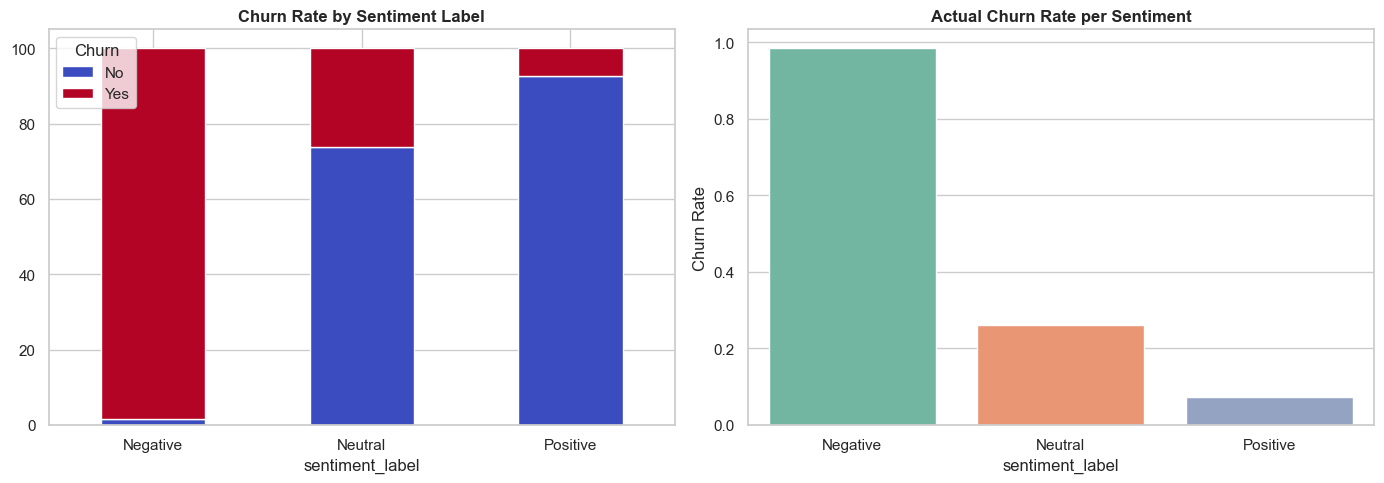


Distribusi Sentiment:
sentiment_label
Positive    4371
Neutral     1494
Negative    1178
Name: count, dtype: int64


In [11]:
# ── Tambahkan fitur sentiment ke dataframe utama ───────────────────────────────
all_sent_pred  = sent_clf.predict(all_feedback_embeddings)
all_sent_proba = sent_clf.predict_proba(all_feedback_embeddings)
classes        = sent_clf.classes_

df['sentiment_label']      = all_sent_pred
df['sentiment_confidence'] = all_sent_proba.max(axis=1)
df['feedback_length']      = df['CustomerFeedback'].str.len()
df['feedback_word_count']  = df['CustomerFeedback'].str.split().str.len()

for i, cls in enumerate(classes):
    df[f'sent_prob_{cls.lower()}'] = all_sent_proba[:, i]

# Visualisasi sentimen vs churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pd.crosstab(df['sentiment_label'], df['Churn'], normalize='index').mul(100)  .plot(kind='bar', stacked=True, ax=axes[0], colormap='coolwarm')
axes[0].set_title('Churn Rate by Sentiment Label', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

sns.barplot(
    data=df.groupby('sentiment_label')['ChurnLabel'].mean().reset_index(),
    x='sentiment_label', y='ChurnLabel', palette='Set2', ax=axes[1]
)
axes[1].set_title('Actual Churn Rate per Sentiment', fontweight='bold')
axes[1].set_ylabel('Churn Rate')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sentiment_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDistribusi Sentiment:")
print(df['sentiment_label'].value_counts())

---
## 🔧 Phase 4 — Feature Engineering

Feature engineering adalah yang membedakan model *biasa* vs model *level industri*.
Kita tidak hanya memakai fitur mentah — kita ciptakan fitur turunan yang lebih informatif.

**Fitur yang dibuat:**
| Fitur Baru | Formula | Alasan |
|---|---|---|
| `avg_monthly_charge` | TotalCharges / tenure | Spending rate sesungguhnya |
| `is_new_customer` | tenure ≤ 6 | Customer baru lebih rentan churn |
| `num_services` | count layanan aktif | Makin banyak layanan = lebih loyal |
| `spending_rate` | MonthlyCharges / median | Relatif mahal atau murah? |
| `charge_per_service` | MonthlyCharges / num_services | Cost efficiency customer |
| `has_internet` | InternetService != 'No' | Binary flag untuk segmentasi |

> **Catatan penting**: `CustomerFeedback` (teks mentah) TIDAK dimasukkan sebagai fitur model.
> Yang masuk adalah *representasi numeriknya* (sentiment scores + PCA embeddings).
> Memasukkan teks mentah langsung = data leakage / feature explosion.


In [12]:
# ── Feature Engineering ───────────────────────────────────────────────────────
df['avg_monthly_charge'] = df['TotalCharges'] / df['tenure'].clip(lower=1)
df['is_new_customer']    = (df['tenure'] <= 6).astype(int)
df['has_internet']       = (df['InternetService'] != 'No').astype(int)

service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies']
df['num_services'] = sum((df[c] == 'Yes').astype(int) for c in service_cols if c in df.columns)

median_charge        = df['MonthlyCharges'].median()
df['spending_rate']  = df['MonthlyCharges'] / median_charge
df['charge_per_service'] = df['MonthlyCharges'] / df['num_services'].clip(lower=1)

print("Fitur baru ditambahkan:")
new_features = ['avg_monthly_charge','is_new_customer','has_internet',
                'num_services','spending_rate','charge_per_service']
print(df[new_features].describe().T[['mean','min','max']])
print(f"\nTotal kolom sekarang: {df.shape[1]}")

Fitur baru ditambahkan:
                         mean        min         max
avg_monthly_charge  64.698218   0.000000  121.400000
is_new_customer      0.210280   0.000000    1.000000
has_internet         0.783331   0.000000    1.000000
num_services         2.037910   0.000000    6.000000
spending_rate        0.920564   0.259417    1.687989
charge_per_service  33.692385  10.416667   87.050000

Total kolom sekarang: 36


---
## 🤖 Phase 5 — Model Training & Comparison

**Stack model yang dibandingkan:**
1. **CatBoost** — gradient boosting modern, sangat kuat untuk tabular + kategorikal
2. **Random Forest** — ensemble klasik, robust dan interpretable
3. **Gradient Boosting (sklearn)** — baseline boosting

**Evaluasi:**
- 5-fold Stratified Cross-Validation (lebih robust dari single split)
- Metrik: ROC AUC (prioritas), F1, Precision, Recall
- Test set terpisah untuk evaluasi final

**Mengapa CatBoost diharapkan menang?**
- Tidak perlu OneHotEncoding manual
- Mendukung `auto_class_weights='Balanced'` untuk class imbalance
- Lebih cepat dan stabil dibanding XGBoost untuk data kategorikal


In [13]:
# ── PCA compression embeddings ────────────────────────────────────────────────
# Sebelum training: kompres embeddings 384-dim → N_EMBED_COMPONENTS dim
# Ini penting agar model tidak overwhelmed oleh dimensi embedding

train_idx_full, test_idx_full = train_test_split(
    df.index, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df['ChurnLabel']
)

pca = PCA(n_components=N_EMBED_COMPONENTS, random_state=RANDOM_STATE)
pca.fit(all_feedback_embeddings[df.index.get_indexer(train_idx_full)])
embedding_pca = pca.transform(all_feedback_embeddings)

emb_cols = [f'emb_pc_{i+1}' for i in range(N_EMBED_COMPONENTS)]
emb_df = pd.DataFrame(embedding_pca, columns=emb_cols, index=df.index)

print(f"Variance explained oleh {N_EMBED_COMPONENTS} komponen PCA: "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"Shape embedding terkompres: {embedding_pca.shape}")

Variance explained oleh 24 komponen PCA: 84.2%
Shape embedding terkompres: (7043, 24)


In [14]:
# ── Gabungkan semua fitur ─────────────────────────────────────────────────────
EXCLUDE = {'Churn','ChurnLabel','CustomerFeedback','sentiment_label_proxy',
           'sentiment_label','sentiment_label_proxy'}

combined_df = pd.concat([
    df.drop(columns=[c for c in EXCLUDE if c in df.columns]).copy(),
    emb_df
], axis=1)

# String-ify kolom kategorikal agar CatBoost happy
cat_cols_combined = combined_df.select_dtypes(exclude=['number']).columns.tolist()
for col in cat_cols_combined:
    combined_df[col] = combined_df[col].fillna('missing').astype(str)

X = combined_df
y = df['ChurnLabel']

X_train = X.loc[train_idx_full]
X_test  = X.loc[test_idx_full]
y_train = y.loc[train_idx_full]
y_test  = y.loc[test_idx_full]

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Churn rate train: {y_train.mean()*100:.2f}% | test: {y_test.mean()*100:.2f}%")
print(f"Total fitur: {X.shape[1]}  (tabular + sentiment + {N_EMBED_COMPONENTS} PCA embedding dims)")

Train: 5634 | Test: 1409
Churn rate train: 26.54% | test: 26.54%
Total fitur: 55  (tabular + sentiment + 24 PCA embedding dims)


In [15]:
# ── Training & Evaluasi ───────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
fitted_models = {}

# ── 1) CatBoost ──────────────────────────────────────────────────────────────
print("=" * 55)
print("Training CatBoost...")
cat_pool_train = Pool(X_train, y_train, cat_features=cat_cols_combined)
cat_pool_test  = Pool(X_test,  y_test,  cat_features=cat_cols_combined)

catboost_model = CatBoostClassifier(
    iterations=1000, depth=8, learning_rate=0.04,
    loss_function='Logloss', eval_metric='AUC',
    auto_class_weights='Balanced',
    random_seed=RANDOM_STATE, verbose=False,
    allow_writing_files=False
)
catboost_model.fit(cat_pool_train, eval_set=cat_pool_test, use_best_model=True)

cb_prob = catboost_model.predict_proba(cat_pool_test)[:, 1]
cb_pred = (cb_prob >= 0.5).astype(int)

# CV AUC (approximate — pakai numeric version untuk cross_val_score)
X_num = combined_df.copy()
for col in cat_cols_combined:
    X_num[col] = X_num[col].astype('category').cat.codes
cb_cv = cross_val_score(
    CatBoostClassifier(iterations=300, depth=6, verbose=False,
                       auto_class_weights='Balanced', random_seed=RANDOM_STATE,
                       allow_writing_files=False),
    X_num.loc[train_idx_full], y_train, cv=cv, scoring='roc_auc', n_jobs=-1
)

results.append({
    'model': 'CatBoost',
    'cv_roc_auc_mean': round(cb_cv.mean(), 4),
    'cv_roc_auc_std':  round(cb_cv.std(),  4),
    'test_roc_auc':    round(roc_auc_score(y_test, cb_prob), 4),
    'test_f1':         round(f1_score(y_test, cb_pred), 4),
    'test_precision':  round(precision_score(y_test, cb_pred), 4),
    'test_recall':     round(recall_score(y_test, cb_pred), 4),
})
fitted_models['CatBoost'] = {'model': catboost_model, 'prob': cb_prob, 'pred': cb_pred}
print(f"CatBoost — CV AUC: {cb_cv.mean():.4f} ± {cb_cv.std():.4f} | Test AUC: {results[-1]['test_roc_auc']}")

Training CatBoost...
CatBoost — CV AUC: 0.9991 ± 0.0003 | Test AUC: 0.9998


In [16]:
# ── 2) Random Forest ─────────────────────────────────────────────────────────
print("Training Random Forest...")

# Untuk RF/GB kita butuh preprocessor karena tidak support cat native
num_cols_rf = X_train.select_dtypes(include='number').columns.tolist()
cat_cols_rf = X_train.select_dtypes(exclude='number').columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc',  StandardScaler())]), num_cols_rf),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols_rf),
])

rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=4,
        class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1
    ))
])
rf_cv = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_pipeline.fit(X_train, y_train)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob >= 0.5).astype(int)

results.append({
    'model': 'RandomForest',
    'cv_roc_auc_mean': round(rf_cv.mean(), 4),
    'cv_roc_auc_std':  round(rf_cv.std(),  4),
    'test_roc_auc':    round(roc_auc_score(y_test, rf_prob), 4),
    'test_f1':         round(f1_score(y_test, rf_pred), 4),
    'test_precision':  round(precision_score(y_test, rf_pred), 4),
    'test_recall':     round(recall_score(y_test, rf_pred), 4),
})
fitted_models['RandomForest'] = {'pipeline': rf_pipeline, 'prob': rf_prob, 'pred': rf_pred}
print(f"RandomForest — CV AUC: {rf_cv.mean():.4f} ± {rf_cv.std():.4f} | Test AUC: {results[-1]['test_roc_auc']}")

Training Random Forest...
RandomForest — CV AUC: 0.9966 ± 0.0008 | Test AUC: 0.9976


In [17]:
# ── 3) Gradient Boosting ─────────────────────────────────────────────────────
print("Training Gradient Boosting...")

gb_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        min_samples_leaf=10, subsample=0.8, random_state=RANDOM_STATE
    ))
])
gb_cv = cross_val_score(gb_pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
gb_pipeline.fit(X_train, y_train)
gb_prob = gb_pipeline.predict_proba(X_test)[:, 1]
gb_pred = (gb_prob >= 0.5).astype(int)

results.append({
    'model': 'GradientBoosting',
    'cv_roc_auc_mean': round(gb_cv.mean(), 4),
    'cv_roc_auc_std':  round(gb_cv.std(),  4),
    'test_roc_auc':    round(roc_auc_score(y_test, gb_prob), 4),
    'test_f1':         round(f1_score(y_test, gb_pred), 4),
    'test_precision':  round(precision_score(y_test, gb_pred), 4),
    'test_recall':     round(recall_score(y_test, gb_pred), 4),
})
fitted_models['GradientBoosting'] = {'pipeline': gb_pipeline, 'prob': gb_prob, 'pred': gb_pred}
print(f"GradientBoosting — CV AUC: {gb_cv.mean():.4f} ± {gb_cv.std():.4f} | Test AUC: {results[-1]['test_roc_auc']}")

# ── Comparison Table ─────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('test_roc_auc', ascending=False)
print("\n=== MODEL COMPARISON ===")
display(results_df)

Training Gradient Boosting...
GradientBoosting — CV AUC: 0.9989 ± 0.0003 | Test AUC: 0.9992

=== MODEL COMPARISON ===


,model,cv_roc_auc_mean,cv_roc_auc_std,test_roc_auc,test_f1,test_precision,test_recall
0,CatBoost,0.9991,0.0003,0.9998,0.9825,0.9918,0.9733
2,GradientBoosting,0.9989,0.0003,0.9992,0.9769,0.9945,0.9599
1,RandomForest,0.9966,0.0008,0.9976,0.9663,0.9755,0.9572


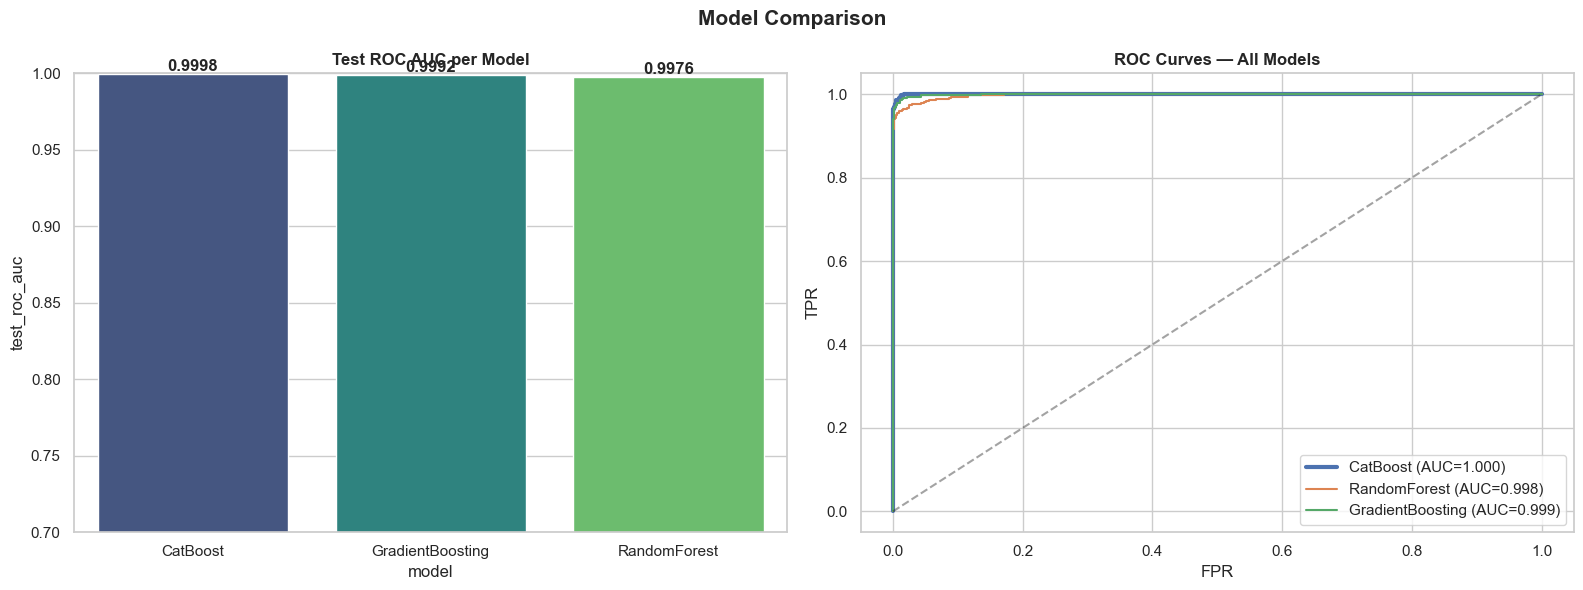


🏆 Best Model: CatBoost
              precision    recall  f1-score   support

           0      0.990     0.997     0.994      1035
           1      0.992     0.973     0.982       374

    accuracy                          0.991      1409
   macro avg      0.991     0.985     0.988      1409
weighted avg      0.991     0.991     0.991      1409



In [18]:
# ── Visualisasi perbandingan + ROC Curve ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison', fontsize=15, fontweight='bold')

# Bar chart AUC
sns.barplot(data=results_df, x='model', y='test_roc_auc', palette='viridis', ax=axes[0])
axes[0].set_ylim(0.7, 1.0)
axes[0].set_title('Test ROC AUC per Model', fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.4f}',
                     (p.get_x()+p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# ROC curves
prob_map = {
    'CatBoost': cb_prob,
    'RandomForest': rf_prob,
    'GradientBoosting': gb_prob,
}
for name, prob in prob_map.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    lw = 3 if name == results_df.iloc[0]['model'] else 1.5
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', linewidth=lw)
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curves — All Models', fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_name = results_df.iloc[0]['model']
print(f"\n🏆 Best Model: {best_name}")
print(classification_report(y_test,
    fitted_models[best_name].get('pred', fitted_models[best_name].get('pred')), digits=3))

---
## 🔍 Phase 6 — SHAP Explainability

**SHAP** (SHapley Additive exPlanations) menjawab pertanyaan paling penting:
> *"Kenapa model memprediksi customer ini akan churn?"*

Ini bukan hanya berguna untuk developer — ini **ditampilkan ke user di web** kamu
sehingga tim bisnis/CS bisa mengambil keputusan berbasis data, bukan intuisi.

**Dua plot utama:**
- **Summary Plot** — fitur mana yang paling berpengaruh secara global
- **Bar Plot** — ranking rata-rata kontribusi absolut fitur

**Untuk FastAPI:** SHAP values per customer akan ikut diekspor dalam JSON response,
sehingga frontend bisa render bar chart "Top Reasons to Churn" per customer.


Menghitung SHAP values (ini mungkin butuh 1-2 menit)...


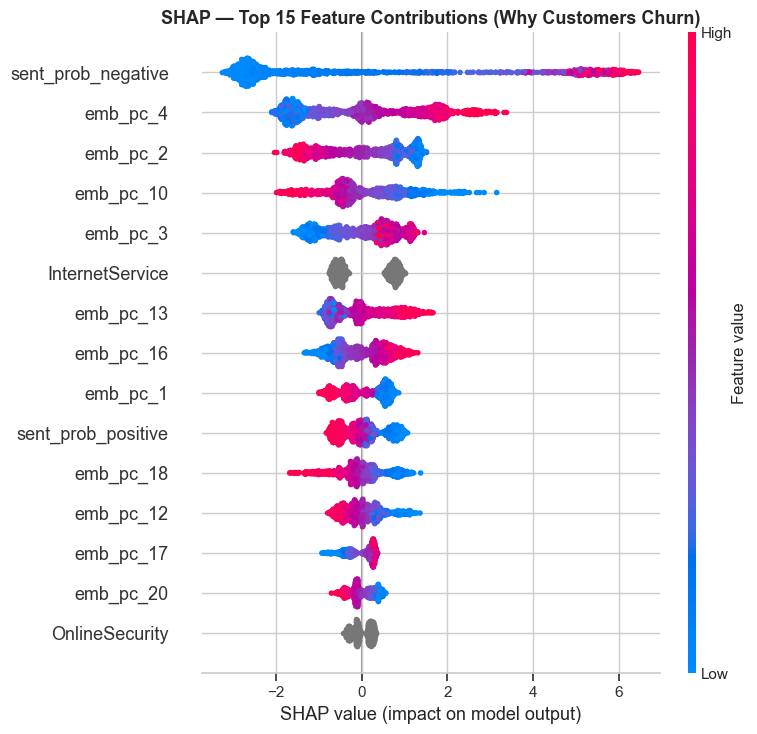

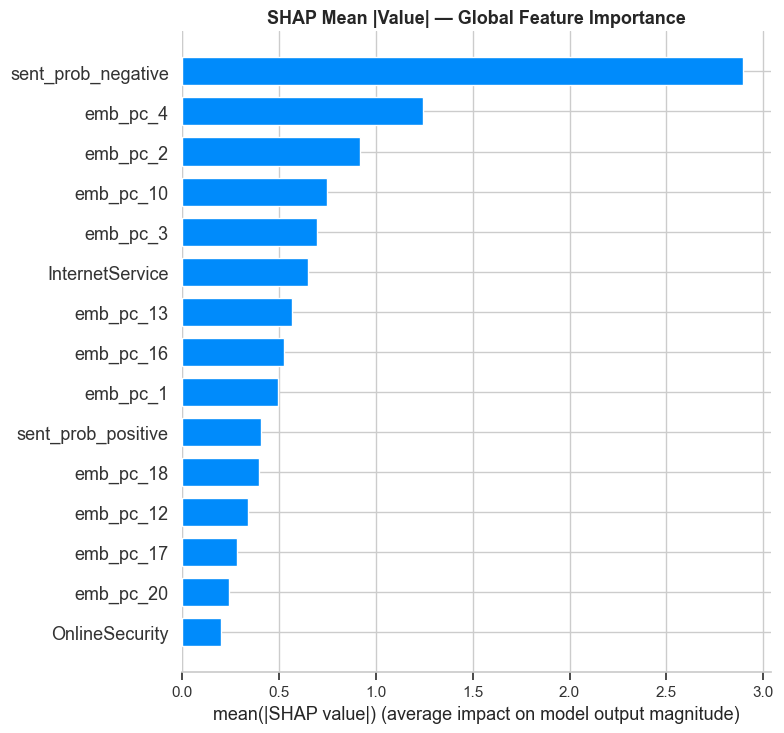

✅ SHAP analysis selesai.


In [19]:
# ── SHAP untuk CatBoost (best model) ─────────────────────────────────────────
print("Menghitung SHAP values (ini mungkin butuh 1-2 menit)...")

try:
    # CatBoost memiliki SHAP built-in via TreeExplainer
    shap_explainer = shap.TreeExplainer(catboost_model)
    X_test_cat = Pool(X_test, cat_features=cat_cols_combined)
    shap_values = catboost_model.get_feature_importance(
        X_test_cat, type='ShapValues'
    )[:, :-1]  # drop bias column

    feature_names = combined_df.columns.tolist()

    # Summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test.values,
                      feature_names=feature_names,
                      show=False, max_display=15)
    plt.title('SHAP — Top 15 Feature Contributions (Why Customers Churn)',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Bar plot
    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_values, X_test.values,
                      feature_names=feature_names,
                      plot_type='bar', show=False, max_display=15)
    plt.title('SHAP Mean |Value| — Global Feature Importance',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/shap_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ SHAP analysis selesai.")

    # Simpan shap_values untuk referensi
    SHAP_AVAILABLE = True

except Exception as e:
    print(f"⚠️  SHAP error (non-fatal): {e}")
    shap_values = None
    SHAP_AVAILABLE = False

---
## 📋 Phase 7 — Risk Scoring & Business Recommendations

Setiap customer mendapatkan output terstruktur:
- **`churn_probability`** — 0.0 s/d 1.0
- **`risk_tier`** — High / Medium / Low
- **`top_churn_factors`** — penjelasan faktor risiko utama
- **`recommended_action`** — tindakan konkret untuk tim CS

Format output ini *persis* yang akan dikembalikan oleh endpoint FastAPI kamu.


In [20]:
# ── Fungsi Risk Scoring ───────────────────────────────────────────────────────
def get_risk_tier(prob):
    if prob >= HIGH_RISK_THR: return 'High'
    if prob >= MED_RISK_THR:  return 'Medium'
    return 'Low'

def get_top_churn_factors(row):
    factors = []
    if str(row.get('Contract','')).lower() == 'month-to-month':
        factors.append('Kontrak bulanan (fleksibel = risiko tinggi)')
    if row.get('tenure', 99) <= 12:
        factors.append(f"Tenure pendek ({int(row.get('tenure',0))} bulan)")
    if row.get('MonthlyCharges', 0) > 70:
        factors.append(f"Tagihan bulanan tinggi (${row.get('MonthlyCharges',0):.2f})")
    if row.get('sentiment_label') == 'Negative':
        conf = row.get('sentiment_confidence', 0)
        factors.append(f"Feedback negatif (confidence {conf:.0%})")
    if str(row.get('InternetService','')).lower() == 'fiber optic':
        factors.append('Fiber optic (segmen churn tinggi)')
    if str(row.get('TechSupport','')).lower() == 'no':
        factors.append('Tidak ada Tech Support')
    if str(row.get('OnlineSecurity','')).lower() == 'no':
        factors.append('Tidak ada Online Security')
    if 'electronic check' in str(row.get('PaymentMethod','')).lower():
        factors.append('Pembayaran electronic check')
    if row.get('num_services', 10) <= 2:
        factors.append('Hanya berlangganan sedikit layanan')
    return '; '.join(factors[:5]) if factors else 'Tidak ada sinyal risiko dominan'

def get_recommendation(risk_tier, row):
    if risk_tier == 'High':
        recs = []
        if str(row.get('Contract','')).lower() == 'month-to-month':
            recs.append('Tawarkan kontrak tahunan diskon 20-30%')
        if row.get('MonthlyCharges', 0) > 70:
            recs.append('Tawarkan loyalty bonus atau pengurangan biaya')
        if str(row.get('TechSupport','')).lower() == 'no':
            recs.append('Berikan trial Tech Support gratis')
        if row.get('sentiment_label') == 'Negative':
            recs.append('PRIORITAS: Outreach personal oleh tim Customer Success')
        return '; '.join(recs[:3]) if recs else 'Retention call segera + penawaran personal'
    elif risk_tier == 'Medium':
        recs = ['Masukkan ke kampanye CRM tersegmentasi']
        if str(row.get('Contract','')).lower() == 'month-to-month':
            recs.append('Kirim promosi upgrade kontrak')
        return '; '.join(recs)
    else:
        return 'Monitor rutin; ikutkan program loyalty reward'

print("✅ Fungsi risk scoring & recommendation siap.")

✅ Fungsi risk scoring & recommendation siap.


In [21]:
# ── Score semua customer ──────────────────────────────────────────────────────
all_cat_pool = Pool(combined_df, cat_features=cat_cols_combined)
df['churn_probability'] = catboost_model.predict_proba(all_cat_pool)[:, 1]
df['churn_prediction']  = np.where(df['churn_probability'] >= 0.5, 'Yes', 'No')
df['risk_tier']         = df['churn_probability'].apply(get_risk_tier)
df['top_churn_factors'] = df.apply(get_top_churn_factors, axis=1)
df['recommended_action']= df.apply(lambda r: get_recommendation(r['risk_tier'], r), axis=1)

# Report distribusi
print("\nRisk Tier Distribution:")
for tier in ['High', 'Medium', 'Low']:
    subset = df[df['risk_tier'] == tier]
    actual_churn = subset['ChurnLabel'].mean() * 100
    print(f"  {tier:8s}: {len(subset):5d} customers ({len(subset)/len(df)*100:.1f}%) "
          f"— Actual Churn Rate: {actual_churn:.1f}%")


Risk Tier Distribution:
  High    :  1859 customers (26.4%) — Actual Churn Rate: 99.9%
  Medium  :     6 customers (0.1%) — Actual Churn Rate: 33.3%
  Low     :  5178 customers (73.5%) — Actual Churn Rate: 0.2%


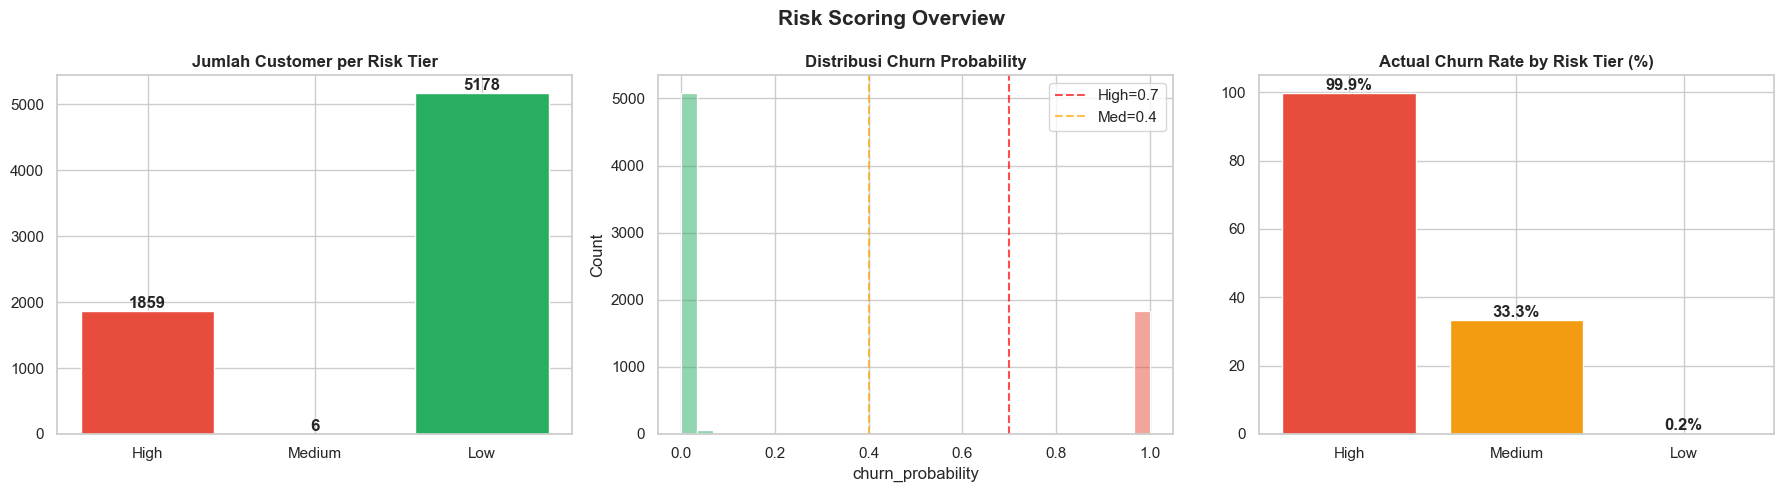

In [22]:
# ── Visualisasi Risk Scoring ─────────────────────────────────────────────────
colors = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#27ae60'}
tier_order = ['High', 'Medium', 'Low']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Risk Scoring Overview', fontsize=15, fontweight='bold')

# Count
tier_counts = [df[df['risk_tier']==t].shape[0] for t in tier_order]
bars = axes[0].bar(tier_order, tier_counts, color=[colors[t] for t in tier_order])
axes[0].set_title('Jumlah Customer per Risk Tier', fontweight='bold')
for bar, cnt in zip(bars, tier_counts):
    axes[0].annotate(str(cnt), (bar.get_x()+bar.get_width()/2., bar.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Probability histogram
sns.histplot(data=df, x='churn_probability', hue='risk_tier',
             ax=axes[1], bins=30, palette=colors, hue_order=tier_order)
axes[1].axvline(HIGH_RISK_THR, color='red',    linestyle='--', alpha=0.7, label=f'High={HIGH_RISK_THR}')
axes[1].axvline(MED_RISK_THR,  color='orange', linestyle='--', alpha=0.7, label=f'Med={MED_RISK_THR}')
axes[1].set_title('Distribusi Churn Probability', fontweight='bold')
axes[1].legend()

# Actual churn rate per tier
tier_churn = [df[df['risk_tier']==t]['ChurnLabel'].mean()*100 for t in tier_order]
bars = axes[2].bar(tier_order, tier_churn, color=[colors[t] for t in tier_order])
axes[2].set_title('Actual Churn Rate by Risk Tier (%)', fontweight='bold')
for bar, rate in zip(bars, tier_churn):
    axes[2].annotate(f'{rate:.1f}%', (bar.get_x()+bar.get_width()/2., bar.get_height()),
                     ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/risk_scoring.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ── Contoh output per customer (format JSON = persis response FastAPI) ────────
print("=== CONTOH OUTPUT: Top 5 High Risk Customers ===\n")
high_risk = df[df['risk_tier']=='High'].sort_values('churn_probability', ascending=False)
for _, row in high_risk.head(5).iterrows():
    out = {
        "churn_probability":  round(row['churn_probability'], 4),
        "churn_prediction":   row['churn_prediction'],
        "risk_tier":          row['risk_tier'],
        "sentiment_label":    row['sentiment_label'],
        "sentiment_confidence": round(row['sentiment_confidence'], 3),
        "top_churn_factors":  row['top_churn_factors'],
        "recommended_action": row['recommended_action'],
    }
    print(json.dumps(out, indent=2, ensure_ascii=False))
    print()

=== CONTOH OUTPUT: Top 5 High Risk Customers ===

{
  "churn_probability": 1.0,
  "churn_prediction": "Yes",
  "risk_tier": "High",
  "sentiment_label": "Negative",
  "sentiment_confidence": 0.55,
  "top_churn_factors": "Kontrak bulanan (fleksibel = risiko tinggi); Tenure pendek (12 bulan); Tagihan bulanan tinggi ($91.30); Feedback negatif (confidence 55%); Fiber optic (segmen churn tinggi)",
  "recommended_action": "Tawarkan kontrak tahunan diskon 20-30%; Tawarkan loyalty bonus atau pengurangan biaya; Berikan trial Tech Support gratis"
}

{
  "churn_probability": 1.0,
  "churn_prediction": "Yes",
  "risk_tier": "High",
  "sentiment_label": "Negative",
  "sentiment_confidence": 0.702,
  "top_churn_factors": "Kontrak bulanan (fleksibel = risiko tinggi); Tenure pendek (8 bulan); Tagihan bulanan tinggi ($86.55); Feedback negatif (confidence 70%); Fiber optic (segmen churn tinggi)",
  "recommended_action": "Tawarkan kontrak tahunan diskon 20-30%; Tawarkan loyalty bonus atau pengurangan bia

---
## 💾 Phase 8 — Export Artefak untuk FastAPI Deployment

Semua artefak disimpan dalam struktur yang siap langsung di-load oleh FastAPI.

### Struktur file output:
```
models/
├── catboost_main_model.cbm          ← model utama CatBoost
├── sentiment_classifier.joblib      ← LogReg di atas embeddings
├── embedding_pca.joblib             ← PCA compressor
└── model_metadata.json             ← konfigurasi, feature lists, threshold

output/
├── churn_intelligence_results.csv  ← hasil scoring semua customer
├── eda_overview.png
├── eda_categorical.png
├── eda_distributions.png
├── sentiment_vs_churn.png
├── model_comparison.png
├── shap_summary.png
└── shap_bar.png
```

### Cara load di FastAPI:
```python
from catboost import CatBoostClassifier, Pool
import joblib, json

catboost_model = CatBoostClassifier()
catboost_model.load_model('models/catboost_main_model.cbm')
sent_clf = joblib.load('models/sentiment_classifier.joblib')
pca      = joblib.load('models/embedding_pca.joblib')
meta     = json.load(open('models/model_metadata.json'))
embedder = SentenceTransformer(meta['embed_model_name'])
```

### Contoh endpoint FastAPI:
```python
@app.post("/predict")
def predict(payload: CustomerInput):
    # 1. Embed feedback
    emb = embedder.encode([payload.customer_feedback], normalize_embeddings=True)
    emb_pca = pca.transform(emb)
    # 2. Sentiment
    sentiment = sent_clf.predict(emb)[0]
    sent_conf = sent_clf.predict_proba(emb).max()
    # 3. Gabungkan fitur → predict
    ...
    return {"churn_probability": prob, "risk_tier": tier, "recommendation": rec}
```


In [24]:
# ── Simpan model CatBoost ─────────────────────────────────────────────────────
catboost_model.save_model(f'{MODEL_DIR}/catboost_main_model.cbm')
print(f"✅ CatBoost saved: {MODEL_DIR}/catboost_main_model.cbm")

# ── Simpan artefak NLP ────────────────────────────────────────────────────────
joblib.dump(sent_clf, f'{MODEL_DIR}/sentiment_classifier.joblib')
joblib.dump(pca,      f'{MODEL_DIR}/embedding_pca.joblib')
# NOTE: SentenceTransformer embedder di-load ulang dari HuggingFace saat runtime
# tidak perlu disimpan karena modelnya kecil dan cepat didownload
print(f"✅ Sentiment classifier & PCA saved.")

# ── Metadata lengkap ─────────────────────────────────────────────────────────
metadata = {
    'notebook_version':     'production_v1',
    'embed_model_name':     EMBED_MODEL_NAME,
    'n_embed_components':   N_EMBED_COMPONENTS,
    'random_state':         RANDOM_STATE,
    'test_size':            TEST_SIZE,
    'risk_thresholds': {
        'high':   HIGH_RISK_THR,
        'medium': MED_RISK_THR,
    },
    'cat_cols_combined':    cat_cols_combined,
    'model_comparison':     results_df.to_dict(orient='records'),
    'best_model':           'CatBoost',
    'fastapi_input_fields': [
        'gender','SeniorCitizen','Partner','Dependents','tenure',
        'PhoneService','MultipleLines','InternetService','OnlineSecurity',
        'OnlineBackup','DeviceProtection','TechSupport','StreamingTV',
        'StreamingMovies','Contract','PaperlessBilling','PaymentMethod',
        'MonthlyCharges','TotalCharges','CustomerFeedback'
    ],
    'fastapi_output_fields': [
        'churn_probability','churn_prediction','risk_tier',
        'sentiment_label','sentiment_confidence',
        'top_churn_factors','recommended_action'
    ]
}
with open(f'{MODEL_DIR}/model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f"✅ Metadata saved.")

# ── Results CSV ───────────────────────────────────────────────────────────────
output_cols = [c for c in [
    'gender','SeniorCitizen','Partner','Dependents','tenure','Contract',
    'PaymentMethod','MonthlyCharges','TotalCharges','Churn',
    'sentiment_label','sentiment_confidence',
    'num_services','is_new_customer','avg_monthly_charge',
    'churn_probability','churn_prediction','risk_tier',
    'top_churn_factors','recommended_action'
] if c in df.columns]

df[output_cols].to_csv(f'{OUTPUT_DIR}/churn_intelligence_results.csv', index=False)
print(f"✅ Results CSV saved ({len(df)} customers).")
print(f"\n{'='*55}")
print("EXPORT SELESAI — Siap untuk FastAPI deployment!")
print(f"{'='*55}")

✅ CatBoost saved: models/catboost_main_model.cbm
✅ Sentiment classifier & PCA saved.
✅ Metadata saved.
✅ Results CSV saved (7043 customers).

EXPORT SELESAI — Siap untuk FastAPI deployment!


---
## 📊 Summary — Production Churn Intelligence System

| Aspek | Detail |
|---|---|
| **NLP Engine** | Sentence Transformers `all-MiniLM-L6-v2` (semantic embedding) |
| **Main Model** | CatBoost (tabular + sentiment + PCA embedding) |
| **Validation** | 5-fold Stratified Cross-Validation |
| **Explainability** | SHAP TreeExplainer (per-customer reasons) |
| **Risk Tiers** | High (≥0.70) / Medium (0.40-0.70) / Low (<0.40) |
| **Deployment** | FastAPI-ready: `.cbm` + `.joblib` + `.json` |
| **Output per Customer** | Probability + Risk Tier + Factors + Recommendation |

### Alur Inference di FastAPI (ringkas)
1. Terima input customer (JSON)
2. Hitung derived features (avg_monthly_charge, num_services, dll)
3. Encode `CustomerFeedback` via Sentence Transformers → PCA
4. Prediksi sentiment via `sent_clf`
5. Gabungkan semua → predict via `catboost_model`
6. Return JSON: probability + tier + factors + recommendation

> **Langkah selanjutnya**: Bungkus notebook ini menjadi `predictor.py`
> lalu expose via `main.py` (FastAPI). Semua artefak di `models/` tinggal di-load saat startup.
